Understanding Generative and Discriminative Models Using MNIST

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Original training data shape:", X_train.shape)
print("Original testing data shape:", X_test.shape)

Original training data shape: (60000, 28, 28)
Original testing data shape: (10000, 28, 28)


In [ ]:
# Select only images containing digit 0 or digit 1

train_filter = (y_train == 0) | (y_train == 1)
test_filter = (y_test == 0) | (y_test == 1)

X_train = X_train[train_filter]
y_train = y_train[train_filter]

X_test = X_test[test_filter]
y_test = y_test[test_filter]

print("Training images after filtering:", X_train.shape)
print("Testing images after filtering:", X_test.shape)

Training images after filtering: (12665, 28, 28)
Testing images after filtering: (2115, 28, 28)


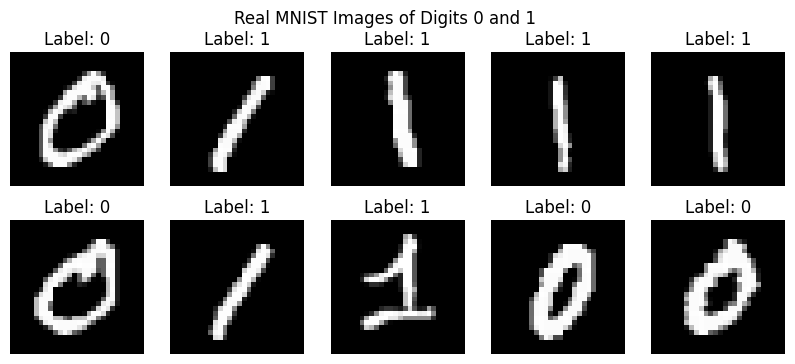

In [ ]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.suptitle("Real MNIST Images of Digits 0 and 1")
plt.show()

In [ ]:
# Flatten images from 28x28 to 784 values
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Normalize pixel values between 0 and 1
X_train_flat = X_train_flat / 255.0
X_test_flat = X_test_flat / 255.0

print("New training shape:", X_train_flat.shape)

New training shape: (12665, 784)


In [ ]:
# Create Logistic Regression model
discriminative_model = LogisticRegression(max_iter=1000)

# Train the model
discriminative_model.fit(X_train_flat, y_train)

print("Model training completed!")

Model training completed!


In [ ]:
# Predict the test images
predictions = discriminative_model.predict(X_test_flat)

# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)

print("Discriminative Model Accuracy:", accuracy)

Discriminative Model Accuracy: 0.9995271867612293


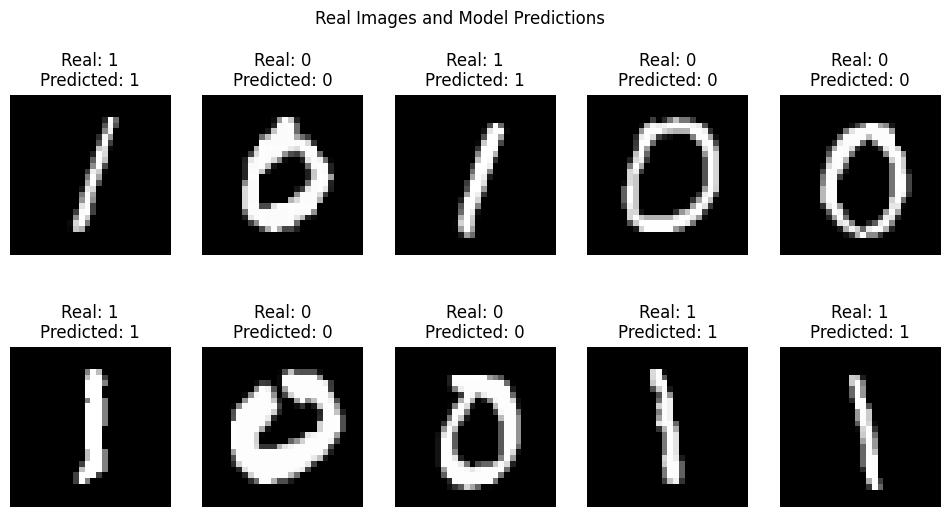

In [ ]:
plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(X_test[i], cmap="gray")

    plt.title(
        f"Real: {y_test[i]}\nPredicted: {predictions[i]}"
    )

    plt.axis("off")

plt.suptitle("Real Images and Model Predictions")
plt.show()

In [ ]:
# Normalize the image pixel values
X_train_auto = X_train.astype("float32") / 255.0
X_test_auto = X_test.astype("float32") / 255.0

# Flatten images
X_train_auto = X_train_auto.reshape(len(X_train_auto), 784)
X_test_auto = X_test_auto.reshape(len(X_test_auto), 784)

print(X_train_auto.shape)

(12665, 784)


In [ ]:
# Input layer
input_layer = Input(shape=(784,))

# Encoder
encoded = Dense(128, activation="relu")(input_layer)
encoded = Dense(32, activation="relu")(encoded)

# Decoder
decoded = Dense(128, activation="relu")(encoded)
decoded = Dense(784, activation="sigmoid")(decoded)

# Create Autoencoder
autoencoder = Model(input_layer, decoded)

# Compile the model
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

# Display model summary
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = autoencoder.fit(
    X_train_auto,
    X_train_auto,
    epochs=10,
    batch_size=256,
    validation_data=(X_test_auto, X_test_auto)
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - loss: 0.3560 - val_loss: 0.1734
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.1552 - val_loss: 0.1391
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.1305 - val_loss: 0.1211
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0.1178 - val_loss: 0.1110
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - loss: 0.1087 - val_loss: 0.1026
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.1007 - val_loss: 0.0953
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0950 - val_loss: 0.0911
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0916 - val_loss: 0.0883
Epoch 9/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0890 - val_loss: 0.0862
Epoch 10/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0866 - val_loss: 0.0838


In [ ]:
X_train_auto,
X_train_auto

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [ ]:
# Generate reconstructed images
generated_images = autoencoder.predict(X_test_auto[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


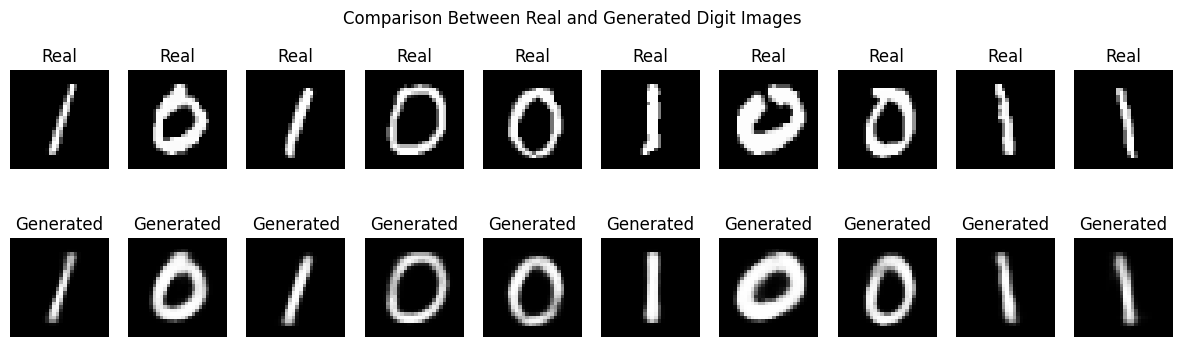

In [ ]:
plt.figure(figsize=(15, 4))

for i in range(10):

    # Original Image
    plt.subplot(2, 10, i + 1)
    plt.imshow(X_test_auto[i].reshape(28, 28), cmap="gray")
    plt.title("Real")
    plt.axis("off")

    # Generated/Reconstructed Image
    plt.subplot(2, 10, i + 11)
    plt.imshow(generated_images[i].reshape(28, 28), cmap="gray")
    plt.title("Generated")
    plt.axis("off")

plt.suptitle("Comparison Between Real and Generated Digit Images")
plt.show()

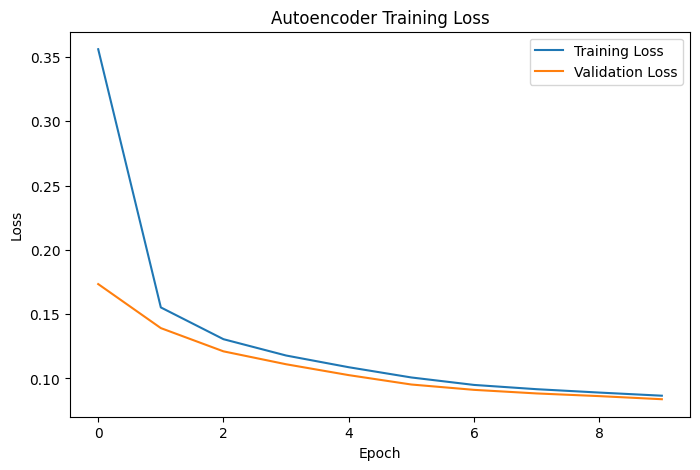

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training Loss")

plt.legend()
plt.show()